# 2D Navier-Stokes — Lid-Driven Cavity

The 2D incompressible Navier-Stokes equations govern viscous fluid flow:

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y} = -\frac{1}{\rho}\frac{\partial p}{\partial x} + \nu\nabla^2 u$$

$$\frac{\partial v}{\partial t} + u\frac{\partial v}{\partial x} + v\frac{\partial v}{\partial y} = -\frac{1}{\rho}\frac{\partial p}{\partial y} + \nu\nabla^2 v$$

Incompressibility is enforced via artificial compressibility: $\partial p/\partial t = -\beta(\partial u/\partial x + \partial v/\partial y)$.

We solve the **lid-driven cavity** — a square domain where the top wall moves at $U=1$ and all other walls are stationary. At $Re = U L / \nu = 100$ the steady solution shows a large primary vortex and two small corner vortices.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import sys; sys.path.insert(0, '..')   # adjust path to upde.py and equations.py
# run pip install -e . to install package
from upde import PDE, PDESystem, NavierStokes2D

In [5]:
Nx, Ny  = 32, 32
Lx, Ly  = 1.0, 1.0
nu      = 0.01      # kinematic viscosity
U_lid   = 1.0       # lid velocity
Re      = U_lid * Lx / nu
print(f'Re = {Re:.0f}')

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

ns = NavierStokes2D('u', 'v', 'p', x=x, y=y, nu=nu, rho=1.0, beta=0.5,pressure_stabilisation = 0.01)

# u BCs: moving lid on top, no-slip everywhere else
ns.u.set_bc(side='top',    kind='dirichlet', value=U_lid)
ns.u.set_bc(side='bottom', kind='dirichlet', value=0.0)
ns.u.set_bc(side='left',   kind='dirichlet', value=0.0)
ns.u.set_bc(side='right',  kind='dirichlet', value=0.0)

# v BCs: no-slip on all walls
ns.v.set_bc(side='top',    kind='dirichlet', value=0.0)
ns.v.set_bc(side='bottom', kind='dirichlet', value=0.0)
ns.v.set_bc(side='left',   kind='dirichlet', value=0.0)
ns.v.set_bc(side='right',  kind='dirichlet', value=0.0)

# p BCs: Neumann everywhere
for side in ('left', 'right', 'bottom', 'top'):
    ns.p.set_bc(side=side, kind='neumann', value=0.0)

ns.u.set_ic(0.0);  ns.v.set_ic(0.0);  ns.p.set_ic(0.0)

print('Solving...')
sol = ns.solve(t_span=(0, 20), method='RK45',
               rtol=1e-4, atol=1e-6)
print(f'Done.  {sol.message}')


Re = 100
Solving...
Done.  The solver successfully reached the end of the integration interval.


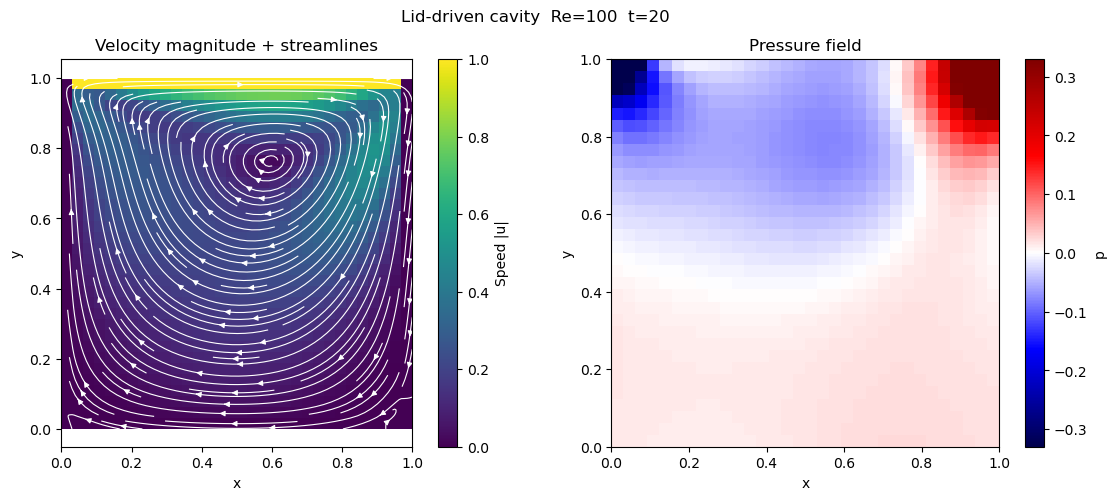

In [6]:
u_f = sol.u[:, :, -1]
v_f = sol.v[:, :, -1]
p_f = sol.p[:, :, -1]
speed = np.sqrt(u_f**2 + v_f**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'Lid-driven cavity  Re={Re:.0f}  t={sol.t[-1]:.0f}', fontsize=12)

# Speed + streamlines
ax = axes[0]
im = ax.imshow(speed.T, origin='lower', aspect='equal',
               extent=[0,Lx,0,Ly], cmap='viridis')
ax.streamplot(x, y, u_f.T, v_f.T, color='w',
              density=1.5, linewidth=0.8, arrowsize=0.8)
plt.colorbar(im, ax=ax, label='Speed |u|')
ax.set_title('Velocity magnitude + streamlines')
ax.set_xlabel('x');  ax.set_ylabel('y')

# Pressure
ax2 = axes[1]
vmax = np.percentile(np.abs(p_f), 98)
im2 = ax2.imshow(p_f.T, origin='lower', aspect='equal',
                 extent=[0,Lx,0,Ly], cmap='seismic', vmin=-vmax, vmax=vmax)
plt.colorbar(im2, ax=ax2, label='p')
ax2.set_title('Pressure field')
ax2.set_xlabel('x');  ax2.set_ylabel('y')

plt.tight_layout();  plt.show()
